**SESSION 3**

**1. 
Load the 'Mall Customers' dataset (or any small customer dataset) and apply the
 DBSCAN algorithm using scikit-learn to cluster users based on their annual income and 
spending score. Print the number of clusters found and the number of noise points detect**ed.

In [176]:
import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings("ignore")

In [178]:
df=pd.read_csv("Mall_Customers.csv")
df.head()

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,CustomerID,Male,19,15,39
1,CustomerID,Male,21,15,81
2,CustomerID,Female,20,16,6
3,CustomerID,Female,23,16,77
4,CustomerID,Female,31,17,40


In [180]:
import matplotlib.pyplot as plt
from sklearn.cluster import DBSCAN
from sklearn.preprocessing import StandardScaler

In [182]:
X=df[["Annual Income (k$)","Spending Score (1-100)"]]

In [184]:
scaler=StandardScaler()
X_scaled=scaler.fit_transform(X)

In [186]:
dbscan=DBSCAN(eps=0.5,min_samples=5)
labels=dbscan.fit_predict(X_scaled)

In [188]:
df["Clusters"]=labels
df.head()

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100),Clusters
0,CustomerID,Male,19,15,39,0
1,CustomerID,Male,21,15,81,0
2,CustomerID,Female,20,16,6,0
3,CustomerID,Female,23,16,77,0
4,CustomerID,Female,31,17,40,0


In [190]:
n_clusters = len(set(labels)) - (1 if -1 in labels else 0)

n_noise = list(labels).count(-1)

print("Number of clusters found:", n_clusters)
print("Number of noise points:", n_noise)

Number of clusters found: 2
Number of noise points: 8


**2. Visualize the DBSCAN clustering results from your previous task using matplotlib — 
plot each cluster in a different color, and mark noise points in black. Add axis labels and a legend for clarity.**

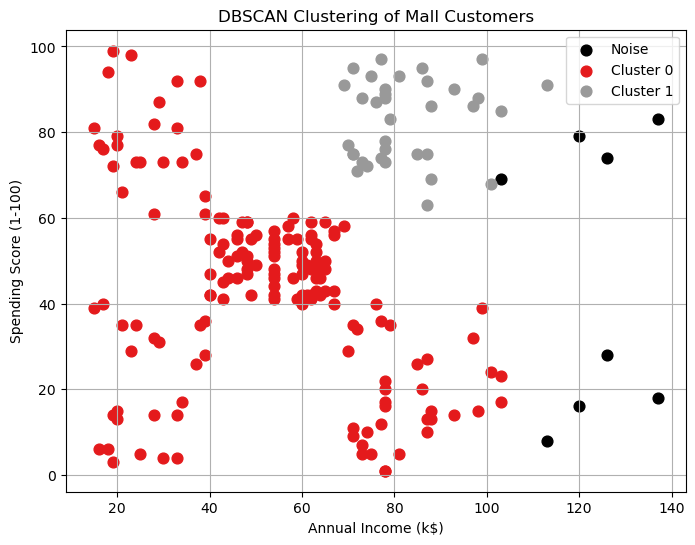

In [193]:
import matplotlib.pyplot as plt
import numpy as np

unique_labels = np.unique(labels)

plt.figure(figsize=(8, 6))

for label in unique_labels:
    if label == -1:
        color = 'black'
        label_name = 'Noise'
    else:
        color = plt.cm.Set1(label / max(unique_labels))
        label_name = f'Cluster {label}'

    cluster_points = df[df['Clusters'] == label]

    plt.scatter(
        cluster_points['Annual Income (k$)'],
        cluster_points['Spending Score (1-100)'],
        c=[color],
        s=60,
        label=label_name
    )

plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score (1-100)")
plt.title("DBSCAN Clustering of Mall Customers")

plt.legend()

plt.grid(True)

plt.show()

**3.
Change the DBSCAN parameters (eps and min_samples) to see how the number of 
clusters and noise points change. Write a short summary (3-4 lines) explaining how parameter 
choices affect the clustering outcome for your dataset.<br><br><em><strong>Hint:</strong>
 Try at least two different values for eps and min_samples, and compare results.</em>**

In [196]:
parameters = [
    (0.3, 5),
    (0.5, 5),
    (0.7, 8)
]
for eps, min_samples in parameters:
    dbscan = DBSCAN(eps=eps, min_samples=min_samples)
    labels = dbscan.fit_predict(X_scaled)

    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    n_noise = list(labels).count(-1)

In [198]:
print(f"eps={eps}, min_samples={min_samples}")
print(f"Clusters Found: {n_clusters}")
print(f"Noise Points: {n_noise}")

eps=0.7, min_samples=8
Clusters Found: 1
Noise Points: 4


**-->When eps is small, DBSCAN forms more clusters and labels more points as noise because fewer points are considered neighbors.**    
**-->Increasing eps allows more nearby points to be grouped together, resulting in fewer clusters and fewer noise points.**  
**-->Increasing min_samples makes it harder to form a cluster, which can increase the number of noise points.**  
**-->Choosing appropriate values for eps and min_samples is important to obtain meaningful clusters for the dataset.**  

**4. Compare DBSCAN and K-Means on the same dataset: run both algorithms, plot their
 cluster assignments side by side, and briefly note which method better handles outliers or 
oddly-shaped clusters.<br><br><em><strong>Constraint:</strong> Use the same features and 
number of clusters (for K-Means) as you observed with DBSCAN.</em>**

In [202]:
from sklearn.cluster import KMeans

In [204]:
kmeans=KMeans(n_clusters=n_clusters, random_state=42,n_init=10)
km=kmeans.fit_predict(X_scaled)

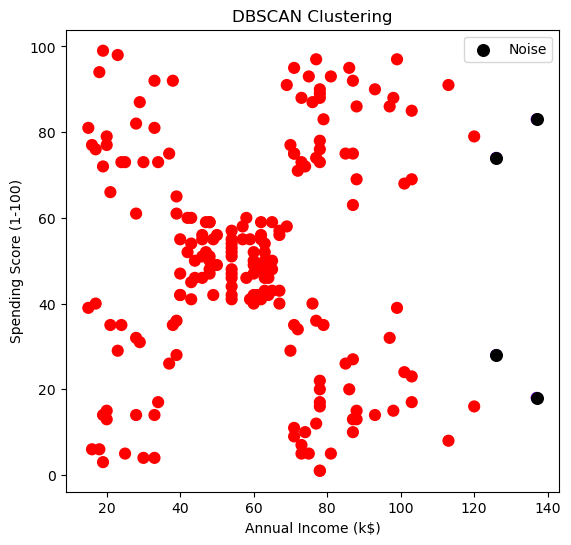

In [206]:
plt.figure(figsize=(14,6))

plt.subplot(1,2,1)
plt.scatter(
    X['Annual Income (k$)'],
    X['Spending Score (1-100)'],
    c=labels,
    cmap='rainbow',
    s=60
)
noise = labels == -1
plt.scatter(
    X.loc[noise, 'Annual Income (k$)'],
    X.loc[noise, 'Spending Score (1-100)'],
    color='black',
    s=70,
    label='Noise'
)

plt.title("DBSCAN Clustering")
plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score (1-100)")
plt.legend()

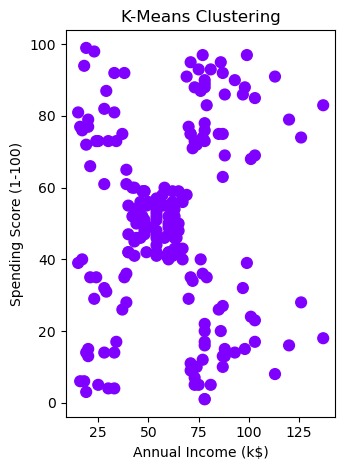

In [210]:
plt.subplot(1,2,2)
plt.scatter(
    X['Annual Income (k$)'],
    X['Spending Score (1-100)'],
    c=km,
    cmap='rainbow',
    s=60
)

plt.title("K-Means Clustering")
plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score (1-100)")

plt.tight_layout()
plt.show()

**Comparison**


**-->DBSCAN can identify noise (outliers) and can detect clusters of irregular shapes without requiring the number of clusters in advance.  
-->K-Means requires the number of clusters (k) to be specified beforehand and assigns every point to a cluster, including outliers.  
-->On the Mall Customers dataset, DBSCAN handles outliers better by labeling them as noise (-1).  
-->K-Means works well for compact, spherical clusters but is more sensitive to outliers than DBSCAN.**  

**5.
Pick a dataset with non-spherical clusters (e.g., make_moons or make_circles from 
sklearn.datasets), and use DBSCAN to cluster the data. Identify 
and print the indices of all points labeled as noise (outliers).**

In [214]:
from sklearn.datasets import make_moons

In [216]:
x,y=make_moons(n_samples=300,noise=0.08,random_state=42)

In [218]:
x_scaled=scaler.fit_transform(x)

In [220]:
dbscan = DBSCAN(eps=0.25, min_samples=5)
labels = dbscan.fit_predict(x_scaled)

In [222]:
noise_indices = np.where(labels == -1)[0]

In [224]:
print("Number of clusters:",
      len(set(labels)) - (1 if -1 in labels else 0))
print("Number of noise points:", len(noise_indices))
print("\nIndices of Noise Points:")
print(noise_indices)

Number of clusters: 2
Number of noise points: 2

Indices of Noise Points:
[ 97 191]


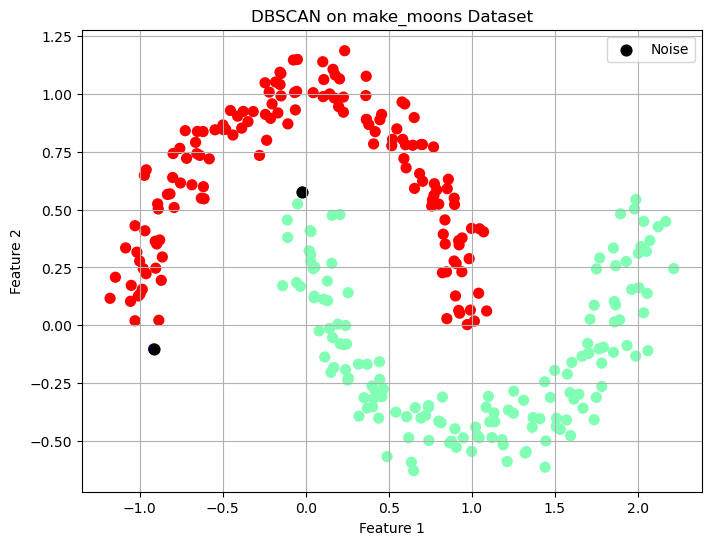

In [230]:
plt.figure(figsize=(8,6))
plt.scatter(
    x[:,0],
    x[:,1],
    c=labels,
    cmap='rainbow',
    s=50
)
plt.scatter(
    x[noise_indices,0],
    x[noise_indices,1],
    color='black',
    s=60,
    label='Noise'
)

plt.title("DBSCAN on make_moons Dataset")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.legend()
plt.grid(True)

plt.show()